# Memo Pilot Test

Create a preliminary implementation (pilot) of the research design you outlined in your memo of this week. Use the techniques and frameworks introduced in this assignment to demonstrate how your proposed approach can be operationalized.

<font color="purple">**Reminder:** To complete this week’s off-class work, please fill out the survey using the [link](https://forms.gle/N6wyqTxbzRWGTKtL7). Thank you for your feedback!</font>

In [ ]:
# Mount Google Drive and set up directories
from google.colab import drive
try:
    drive.mount('/content/drive')
except:
    print("Drive already mounted")

import os
import json
import numpy as np
import pandas as pd

# Set paths
kaggle_json_path = '/content/drive/MyDrive/MACS_37005_AI_Agent_for_Social_Science/Week_3/files/Kaggle/kaggle.json'
work_dir = '/content/drive/MyDrive/MACS_37005_AI_Agent_for_Social_Science/Week_4/files/HTE_analysis'
data_dir = '/content/drive/MyDrive/MACS_37005_AI_Agent_for_Social_Science/Week_3/files/Kaggle/data'

os.makedirs(work_dir, exist_ok=True)

# Check if data exists, if not download it
if not os.path.exists(f'{data_dir}/arxiv-metadata-oai-snapshot.json'):
    # Configure Kaggle credentials
    !mkdir -p ~/.kaggle
    !cp "{kaggle_json_path}" ~/.kaggle/kaggle.json
    !chmod 600 ~/.kaggle/kaggle.json
    !pip install -q kaggle

    os.chdir(data_dir)
    !kaggle datasets download -d Cornell-University/arxiv
    !unzip -o arxiv.zip
    print("Dataset downloaded!")
else:
    print(f"Dataset already exists at: {data_dir}")

# Load sample papers to explore structure
print("\nLoading sample papers to explore data structure...")
sample_papers = []
with open(f'{data_dir}/arxiv-metadata-oai-snapshot.json', 'r') as f:
    for i, line in enumerate(f):
        if i >= 10:
            break
        sample_papers.append(json.loads(line))

# Show all available fields
print("\n" + "="*60)
print("AVAILABLE FIELDS IN ARXIV DATASET")
print("="*60)

first_paper = sample_papers[0]
for key, value in first_paper.items():
    value_type = type(value).__name__
    if isinstance(value, str):
        preview = value[:80] + "..." if len(value) > 80 else value
        preview = preview.replace('\n', ' ')
    elif isinstance(value, list):
        preview = f"List with {len(value)} items"
    elif value is None:
        preview = "NULL"
    else:
        preview = str(value)
    print(f"\n{key} ({value_type}):")
    print(f"  Example: {preview}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset already exists at: /content/drive/MyDrive/MACS_37005_AI_Agent_for_Social_Science/Week_3/files/Kaggle/data

Loading sample papers to explore data structure...

AVAILABLE FIELDS IN ARXIV DATASET

id (str):
  Example: 0704.0001

submitter (str):
  Example: Pavel Nadolsky

authors (str):
  Example: C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-P. Yuan

title (str):
  Example: Calculation of prompt diphoton production cross sections at Tevatron and   LHC e...

comments (str):
  Example: 37 pages, 15 figures; published version

journal-ref (str):
  Example: Phys.Rev.D76:013009,2007

doi (str):
  Example: 10.1103/PhysRevD.76.013009

report-no (str):
  Example: ANL-HEP-PR-07-12

categories (str):
  Example: hep-ph

license (NoneType):
  Example: NULL

abstract (str):
  Example:   A fully differential calculation in perturbative quantum chromodynamics is pre..

In [ ]:
import random
import time

# Count total papers and check field availability
print("Counting total papers and checking field availability...")
print("(This may take a few minutes...)")

total_papers = 0
has_doi = 0
has_categories = 0
has_authors = 0
multi_category = 0

# Sample for detailed analysis
sample_size = 50000
random.seed(42)

# First pass: count total
with open(f'{data_dir}/arxiv-metadata-oai-snapshot.json', 'r') as f:
    for line in f:
        total_papers += 1

print(f"Total papers in dataset: {total_papers:,}")

# Generate random indices for sampling
sample_indices = set(random.sample(range(total_papers), min(sample_size, total_papers)))

# Second pass: check field availability on sample
papers_sample = []
with open(f'{data_dir}/arxiv-metadata-oai-snapshot.json', 'r') as f:
    for i, line in enumerate(f):
        if i in sample_indices:
            paper = json.loads(line)
            papers_sample.append(paper)

            # Check DOI
            if paper.get('doi') and paper['doi'].strip():
                has_doi += 1

            # Check categories
            if paper.get('categories') and paper['categories'].strip():
                has_categories += 1
                cats = paper['categories'].split()
                if len(cats) > 1:
                    multi_category += 1

            # Check authors
            if paper.get('authors_parsed') and len(paper['authors_parsed']) > 0:
                has_authors += 1

print(f"\n" + "="*60)
print(f"FIELD AVAILABILITY (based on {len(papers_sample):,} sampled papers)")
print("="*60)
print(f"has_doi: {has_doi:,} ({has_doi/len(papers_sample)*100:.1f}%)")
print(f"has_categories: {has_categories:,} ({has_categories/len(papers_sample)*100:.1f}%)")
print(f"multi_category (T=1 candidates): {multi_category:,} ({multi_category/len(papers_sample)*100:.1f}%)")
print(f"has_authors: {has_authors:,} ({has_authors/len(papers_sample)*100:.1f}%)")

# Convert to DataFrame for further analysis
df_sample = pd.DataFrame(papers_sample)

# Extract year from versions
def extract_year(versions):
    try:
        if versions and len(versions) > 0:
            created = versions[0].get('created', '')
            parts = created.split()
            for part in parts:
                if len(part) == 4 and part.isdigit():
                    return int(part)
        return None
    except:
        return None

df_sample['year'] = df_sample['versions'].apply(extract_year)

# Check year distribution
print(f"\n" + "="*60)
print("YEAR DISTRIBUTION")
print("="*60)
year_counts = df_sample['year'].value_counts().sort_index()
print(year_counts.tail(15))

# Check team size distribution
df_sample['team_size'] = df_sample['authors_parsed'].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)
print(f"\n" + "="*60)
print("TEAM SIZE DISTRIBUTION")
print("="*60)
print(df_sample['team_size'].describe())

# Define team size categories as in memo
def categorize_team_size(n):
    if n == 1:
        return 'Solo (1)'
    elif n <= 3:
        return 'Small (2-3)'
    elif n <= 6:
        return 'Medium (4-6)'
    else:
        return 'Large (7+)'

df_sample['team_category'] = df_sample['team_size'].apply(categorize_team_size)
print("\nTeam size categories:")
print(df_sample['team_category'].value_counts())

Counting total papers and checking field availability...
(This may take a few minutes...)
Total papers in dataset: 2,938,427

FIELD AVAILABILITY (based on 50,000 sampled papers)
has_doi: 21,916 (43.8%)
has_categories: 50,000 (100.0%)
multi_category (T=1 candidates): 23,692 (47.4%)
has_authors: 50,000 (100.0%)

YEAR DISTRIBUTION
year
2012    1461
2013    1586
2014    1714
2015    1804
2016    1906
2017    2077
2018    2360
2019    2607
2020    3033
2021    3021
2022    3265
2023    3609
2024    4008
2025    4893
2026     272
Name: count, dtype: int64

TEAM SIZE DISTRIBUTION
count    50000.000000
mean         4.667820
std         23.720523
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max       1661.000000
Name: team_size, dtype: float64

Team size categories:
team_category
Small (2-3)     22263
Medium (4-6)    13034
Solo (1)         9052
Large (7+)       5651
Name: count, dtype: int64


In [ ]:
# Test Semantic Scholar API with arXiv IDs
import requests
import time

print("Testing Semantic Scholar API...")
print("="*60)

# Get a few sample arXiv IDs
test_ids = df_sample[df_sample['year'].between(2015, 2020)]['id'].head(10).tolist()
print(f"Testing with {len(test_ids)} arXiv IDs: {test_ids[:3]}...")

# Test API call
def get_citation_count(arxiv_id):
    """Get citation count from Semantic Scholar using arXiv ID"""
    url = f"https://api.semanticscholar.org/graph/v1/paper/arXiv:{arxiv_id}"
    params = {"fields": "citationCount,year,title"}

    try:
        response = requests.get(url, params=params, timeout=10)
        if response.status_code == 200:
            data = response.json()
            return {
                'arxiv_id': arxiv_id,
                'citation_count': data.get('citationCount', 0),
                'title': data.get('title', '')[:50],
                'status': 'success'
            }
        elif response.status_code == 404:
            return {'arxiv_id': arxiv_id, 'citation_count': None, 'status': 'not_found'}
        else:
            return {'arxiv_id': arxiv_id, 'citation_count': None, 'status': f'error_{response.status_code}'}
    except Exception as e:
        return {'arxiv_id': arxiv_id, 'citation_count': None, 'status': f'exception: {str(e)[:30]}'}

# Test a few papers
results = []
for arxiv_id in test_ids[:5]:
    result = get_citation_count(arxiv_id)
    results.append(result)
    print(f"  {arxiv_id}: {result['status']}, citations={result.get('citation_count', 'N/A')}")
    time.sleep(0.5)  # Rate limiting

# Check success rate
success_count = sum(1 for r in results if r['status'] == 'success')
print(f"\nAPI Test Results: {success_count}/{len(results)} successful")

if success_count > 0:
    print("\nSemantic Scholar API works! We can use it to get citation data.")
else:
    print("\nAPI may have issues. We might need to use alternative outcome.")

Testing Semantic Scholar API...
Testing with 10 arXiv IDs: ['1501.00247', '1501.00280', '1501.00334']...
  1501.00247: success, citations=3
  1501.00280: success, citations=2
  1501.00334: success, citations=12
  1501.00483: success, citations=28
  1501.00509: success, citations=10

API Test Results: 5/5 successful

Semantic Scholar API works! We can use it to get citation data.


In [ ]:
# Step 4: Strategic sampling for HTE analysis
import random
import time
from collections import defaultdict

print("Step 4: Strategic Sampling for HTE Analysis")
print("="*60)

# Filter papers: 2010-2022 (need time for citations to accumulate)
# Exclude 2023+ because citations haven't accumulated yet
df_filtered = df_sample[
    (df_sample['year'] >= 2010) &
    (df_sample['year'] <= 2022) &
    (df_sample['team_size'] > 0) &
    (df_sample['team_size'] <= 50)  # Remove outliers
].copy()

print(f"Papers after filtering (2010-2022, team_size<=50): {len(df_filtered):,}")

# Define temporal periods as in memo
def get_temporal_period(year):
    if 2010 <= year <= 2014:
        return 'Early (2010-2014)'
    elif 2015 <= year <= 2019:
        return 'Middle (2015-2019)'
    elif 2020 <= year <= 2024:
        return 'Recent (2020-2024)'
    else:
        return None

df_filtered['temporal_period'] = df_filtered['year'].apply(get_temporal_period)
df_filtered = df_filtered[df_filtered['temporal_period'].notna()]

# Define treatment: multi-category papers (exploring novel combinations)
df_filtered['num_categories'] = df_filtered['categories'].apply(
    lambda x: len(x.split()) if pd.notna(x) else 0
)
df_filtered['is_novel_combination'] = (df_filtered['num_categories'] > 1).astype(int)

# Check distribution across subgroups
print("\nDistribution across HTE dimensions:")
print("-"*40)
cross_tab = pd.crosstab(
    df_filtered['team_category'],
    df_filtered['temporal_period'],
    margins=True
)
print(cross_tab)

print("\nTreatment distribution:")
print(df_filtered['is_novel_combination'].value_counts())

# Stratified sampling: sample from each subgroup
# Target: ~500 papers per subgroup for statistical power
target_per_subgroup = 400
subgroups = []

for team_cat in ['Solo (1)', 'Small (2-3)', 'Medium (4-6)', 'Large (7+)']:
    for period in ['Early (2010-2014)', 'Middle (2015-2019)', 'Recent (2020-2024)']:
        mask = (df_filtered['team_category'] == team_cat) & (df_filtered['temporal_period'] == period)
        subgroup_df = df_filtered[mask]

        # Sample up to target_per_subgroup
        n_sample = min(target_per_subgroup, len(subgroup_df))
        if n_sample > 0:
            sampled = subgroup_df.sample(n=n_sample, random_state=42)
            subgroups.append(sampled)
            print(f"  {team_cat} x {period}: sampled {n_sample}")

# Combine all samples
df_hte_sample = pd.concat(subgroups, ignore_index=True)
print(f"\nTotal papers for HTE analysis: {len(df_hte_sample):,}")

# Verify stratification
print("\nVerify stratification:")
print(pd.crosstab(df_hte_sample['team_category'], df_hte_sample['temporal_period']))

Step 4: Strategic Sampling for HTE Analysis
Papers after filtering (2010-2022, team_size<=50): 27,153

Distribution across HTE dimensions:
----------------------------------------
temporal_period  Early (2010-2014)  Middle (2015-2019)  Recent (2020-2024)  \
team_category                                                                
Large (7+)                     548                1068                1100   
Medium (4-6)                  1407                2742                2963   
Small (2-3)                   3518                5080                4012   
Solo (1)                      1705                1813                1197   
All                           7178               10703                9272   

temporal_period    All  
team_category           
Large (7+)        2716  
Medium (4-6)      7112  
Small (2-3)      12610  
Solo (1)          4715  
All              27153  

Treatment distribution:
is_novel_combination
0    13863
1    13290
Name: count, dtype: int64
  So

In [ ]:
# Step 5: Fetch citation data from Semantic Scholar
import requests
import time
import pickle
from tqdm import tqdm

print("Step 5: Fetching Citation Data from Semantic Scholar")
print("="*60)

# Check if we already have cached results
cache_file = f'{work_dir}/citation_cache.pkl'

if os.path.exists(cache_file):
    print("Loading cached citation data...")
    with open(cache_file, 'rb') as f:
        citation_cache = pickle.load(f)
    print(f"Loaded {len(citation_cache)} cached results")
else:
    citation_cache = {}

# Function to get citation count with retry logic
def get_citation_count_robust(arxiv_id, max_retries=3):
    """Get citation count from Semantic Scholar with retry logic"""
    url = f"https://api.semanticscholar.org/graph/v1/paper/arXiv:{arxiv_id}"
    params = {"fields": "citationCount,year,influentialCitationCount"}

    for attempt in range(max_retries):
        try:
            response = requests.get(url, params=params, timeout=15)
            if response.status_code == 200:
                data = response.json()
                return {
                    'citation_count': data.get('citationCount', 0),
                    'influential_citations': data.get('influentialCitationCount', 0),
                    'status': 'success'
                }
            elif response.status_code == 404:
                return {'citation_count': None, 'status': 'not_found'}
            elif response.status_code == 429:  # Rate limited
                time.sleep(2 ** attempt)  # Exponential backoff
                continue
            else:
                return {'citation_count': None, 'status': f'error_{response.status_code}'}
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(1)
                continue
            return {'citation_count': None, 'status': 'exception'}

    return {'citation_count': None, 'status': 'max_retries'}

# Get list of arXiv IDs to fetch
arxiv_ids = df_hte_sample['id'].tolist()
ids_to_fetch = [aid for aid in arxiv_ids if aid not in citation_cache]

print(f"Total papers: {len(arxiv_ids)}")
print(f"Already cached: {len(citation_cache)}")
print(f"Need to fetch: {len(ids_to_fetch)}")

# Fetch citations (with progress bar)
if len(ids_to_fetch) > 0:
    print(f"\nFetching citations for {len(ids_to_fetch)} papers...")
    print("(This will take approximately {:.0f} minutes)".format(len(ids_to_fetch) * 0.15 / 60))

    batch_size = 100  # Save every 100 papers

    for i, arxiv_id in enumerate(tqdm(ids_to_fetch)):
        result = get_citation_count_robust(arxiv_id)
        citation_cache[arxiv_id] = result

        # Rate limiting: ~100 requests per 5 minutes = 1 request per 3 seconds
        # Being conservative with 0.12 second delay
        time.sleep(0.12)

        # Save cache periodically
        if (i + 1) % batch_size == 0:
            with open(cache_file, 'wb') as f:
                pickle.dump(citation_cache, f)

            # Print progress stats
            success_so_far = sum(1 for k in list(citation_cache.keys())[:i+1]
                                if citation_cache.get(k, {}).get('status') == 'success')
            print(f"  Saved checkpoint: {i+1}/{len(ids_to_fetch)}, success rate: {success_so_far/(i+1)*100:.1f}%")

    # Final save
    with open(cache_file, 'wb') as f:
        pickle.dump(citation_cache, f)
    print(f"\nFinal cache saved to: {cache_file}")

# Apply citation data to dataframe
df_hte_sample['citation_count'] = df_hte_sample['id'].apply(
    lambda x: citation_cache.get(x, {}).get('citation_count', None)
)
df_hte_sample['citation_status'] = df_hte_sample['id'].apply(
    lambda x: citation_cache.get(x, {}).get('status', 'not_fetched')
)

# Check results
print("\n" + "="*60)
print("CITATION DATA SUMMARY")
print("="*60)
print(f"Total papers: {len(df_hte_sample)}")
print(f"Successfully fetched: {(df_hte_sample['citation_status'] == 'success').sum()}")
print(f"Not found: {(df_hte_sample['citation_status'] == 'not_found').sum()}")
print(f"Coverage: {(df_hte_sample['citation_status'] == 'success').mean()*100:.1f}%")

# Citation distribution for successful papers
successful_df = df_hte_sample[df_hte_sample['citation_status'] == 'success']
print(f"\nCitation statistics (for {len(successful_df)} papers):")
print(successful_df['citation_count'].describe())

Step 5: Fetching Citation Data from Semantic Scholar
Total papers: 4800
Already cached: 0
Need to fetch: 4800

Fetching citations for 4800 papers...
(This will take approximately 12 minutes)


  1%|          | 54/4800 [01:19<1:56:00,  1.47s/it]


KeyboardInterrupt: 

In [ ]:
# Step 5 (Optimized): Batch fetch citation data from Semantic Scholar
import requests
import time
import pickle
from tqdm import tqdm

print("Step 5: Fetching Citation Data (Batch Mode)")
print("="*60)

# Check if we already have cached results
cache_file = f'{work_dir}/citation_cache.pkl'

if os.path.exists(cache_file):
    print("Loading cached citation data...")
    with open(cache_file, 'rb') as f:
        citation_cache = pickle.load(f)
    print(f"Loaded {len(citation_cache)} cached results")
else:
    citation_cache = {}

def batch_get_citations(arxiv_ids, batch_size=400):
    """
    Batch fetch citations using Semantic Scholar batch API
    Can query up to 500 papers at once
    """
    url = "https://api.semanticscholar.org/graph/v1/paper/batch"
    params = {"fields": "citationCount,influentialCitationCount,externalIds"}

    results = {}

    # Process in batches
    for i in tqdm(range(0, len(arxiv_ids), batch_size), desc="Fetching batches"):
        batch_ids = arxiv_ids[i:i+batch_size]

        # Format IDs for API
        paper_ids = [f"arXiv:{aid}" for aid in batch_ids]

        try:
            response = requests.post(
                url,
                params=params,
                json={"ids": paper_ids},
                timeout=60
            )

            if response.status_code == 200:
                data = response.json()

                for j, paper in enumerate(data):
                    original_id = batch_ids[j]
                    if paper is not None:
                        results[original_id] = {
                            'citation_count': paper.get('citationCount', 0),
                            'influential_citations': paper.get('influentialCitationCount', 0),
                            'status': 'success'
                        }
                    else:
                        results[original_id] = {
                            'citation_count': None,
                            'status': 'not_found'
                        }
            else:
                print(f"  Batch error: {response.status_code}")
                for aid in batch_ids:
                    results[aid] = {'citation_count': None, 'status': f'error_{response.status_code}'}

        except Exception as e:
            print(f"  Exception: {str(e)[:50]}")
            for aid in batch_ids:
                results[aid] = {'citation_count': None, 'status': 'exception'}

        # Small delay between batches to be respectful to API
        time.sleep(1)

    return results

# Get list of arXiv IDs to fetch
arxiv_ids = df_hte_sample['id'].tolist()
ids_to_fetch = [aid for aid in arxiv_ids if aid not in citation_cache]

print(f"Total papers: {len(arxiv_ids)}")
print(f"Already cached: {len(citation_cache)}")
print(f"Need to fetch: {len(ids_to_fetch)}")

# Fetch citations in batch mode
if len(ids_to_fetch) > 0:
    print(f"\nFetching citations for {len(ids_to_fetch)} papers in batch mode...")
    print(f"(Estimated time: ~{len(ids_to_fetch) // 400 + 1} minutes)")

    new_results = batch_get_citations(ids_to_fetch, batch_size=400)
    citation_cache.update(new_results)

    # Save cache
    with open(cache_file, 'wb') as f:
        pickle.dump(citation_cache, f)
    print(f"Cache saved to: {cache_file}")

# Apply citation data to dataframe
df_hte_sample['citation_count'] = df_hte_sample['id'].apply(
    lambda x: citation_cache.get(x, {}).get('citation_count', None)
)
df_hte_sample['citation_status'] = df_hte_sample['id'].apply(
    lambda x: citation_cache.get(x, {}).get('status', 'not_fetched')
)

# Check results
print("\n" + "="*60)
print("CITATION DATA SUMMARY")
print("="*60)
print(f"Total papers: {len(df_hte_sample)}")
print(f"Successfully fetched: {(df_hte_sample['citation_status'] == 'success').sum()}")
print(f"Not found: {(df_hte_sample['citation_status'] == 'not_found').sum()}")
print(f"Coverage: {(df_hte_sample['citation_status'] == 'success').mean()*100:.1f}%")

# Citation distribution for successful papers
successful_df = df_hte_sample[df_hte_sample['citation_status'] == 'success']
if len(successful_df) > 0:
    print(f"\nCitation statistics (for {len(successful_df)} papers):")
    print(successful_df['citation_count'].describe())

Step 5: Fetching Citation Data (Batch Mode)
Total papers: 4800
Already cached: 0
Need to fetch: 4800

Fetching citations for 4800 papers in batch mode...
(Estimated time: ~13 minutes)


Fetching batches: 100%|██████████| 12/12 [00:29<00:00,  2.50s/it]

Cache saved to: /content/drive/MyDrive/MACS_37005_AI_Agent_for_Social_Science/Week_4/files/HTE_analysis/citation_cache.pkl

CITATION DATA SUMMARY
Total papers: 4800
Successfully fetched: 4774
Not found: 26
Coverage: 99.5%

Citation statistics (for 4774 papers):
count    4774.000000
mean       31.981986
std        97.628759
min         0.000000
25%         3.000000
50%        10.500000
75%        30.000000
max      2892.000000
Name: citation_count, dtype: float64


In [ ]:
# Step 6: Define Outcome and Prepare Data for TARNet
print("Step 6: Define Outcome and Prepare Data")
print("="*60)

# Filter to papers with successful citation data
df_analysis = df_hte_sample[df_hte_sample['citation_status'] == 'success'].copy()
print(f"Papers with citation data: {len(df_analysis)}")

# Get primary category for cohort definition
df_analysis['primary_category'] = df_analysis['categories'].apply(
    lambda x: x.split()[0].split('.')[0] if pd.notna(x) else 'unknown'
)

# Define outcome: top 10% citations within primary_category-year cohort
# This controls for field-specific citation patterns and publication age
def compute_top10_outcome(df):
    """Compute whether paper is in top 10% of its category-year cohort"""
    df = df.copy()
    df['is_top10'] = 0

    # Group by primary category and year
    for (cat, year), group in df.groupby(['primary_category', 'year']):
        if len(group) >= 10:  # Need enough papers for meaningful percentile
            threshold = group['citation_count'].quantile(0.90)
            mask = (df['primary_category'] == cat) & (df['year'] == year)
            df.loc[mask & (df['citation_count'] >= threshold), 'is_top10'] = 1

    return df

df_analysis = compute_top10_outcome(df_analysis)

print(f"\nOutcome distribution:")
print(df_analysis['is_top10'].value_counts())
print(f"Top 10% rate: {df_analysis['is_top10'].mean()*100:.1f}%")

# Check outcome by treatment
print(f"\nOutcome by Treatment (naive):")
outcome_by_treatment = df_analysis.groupby('is_novel_combination')['is_top10'].agg(['mean', 'count'])
outcome_by_treatment.columns = ['top10_rate', 'n_papers']
outcome_by_treatment['top10_rate'] = outcome_by_treatment['top10_rate'] * 100
print(outcome_by_treatment)

# Check outcome distribution across subgroups
print(f"\nTop 10% rate by Team Size and Temporal Period:")
pivot_outcome = df_analysis.pivot_table(
    values='is_top10',
    index='team_category',
    columns='temporal_period',
    aggfunc='mean'
) * 100
print(pivot_outcome.round(1))

# Prepare features for TARNet
print("\n" + "="*60)
print("Preparing features for TARNet")
print("="*60)

# Numeric features
df_analysis['log_team_size'] = np.log1p(df_analysis['team_size'])
df_analysis['abstract_length'] = df_analysis['abstract'].apply(
    lambda x: len(str(x).split()) if pd.notna(x) else 0
)
df_analysis['title_length'] = df_analysis['title'].apply(
    lambda x: len(str(x).split()) if pd.notna(x) else 0
)
df_analysis['num_versions'] = df_analysis['versions'].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

# One-hot encode primary category (top categories only to avoid sparsity)
top_categories = df_analysis['primary_category'].value_counts().head(15).index.tolist()
df_analysis['primary_cat_grouped'] = df_analysis['primary_category'].apply(
    lambda x: x if x in top_categories else 'other'
)

from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Prepare feature matrix
numeric_features = ['log_team_size', 'abstract_length', 'title_length', 'num_versions', 'year']
X_numeric = df_analysis[numeric_features].values

# Scale numeric features
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric)

# One-hot encode categories
cat_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_categorical = cat_encoder.fit_transform(df_analysis[['primary_cat_grouped']])

# Combine features
X = np.concatenate([X_numeric_scaled, X_categorical], axis=1)
feature_names = numeric_features + list(cat_encoder.get_feature_names_out(['primary_cat_grouped']))

print(f"Feature matrix shape: {X.shape}")
print(f"Features: {feature_names}")

# Prepare treatment and outcome
T = df_analysis['is_novel_combination'].values
Y = df_analysis['is_top10'].values

print(f"\nData ready for TARNet:")
print(f"  X shape: {X.shape}")
print(f"  T (treatment): {T.sum()} treated, {len(T) - T.sum()} control")
print(f"  Y (outcome): {Y.sum()} positive, {len(Y) - Y.sum()} negative")

# Save analysis dataframe for later use
df_analysis.to_pickle(f'{work_dir}/df_analysis.pkl')
print(f"\nDataframe saved to: {work_dir}/df_analysis.pkl")


Step 6: Define Outcome and Prepare Data
Papers with citation data: 4774

Outcome distribution:
is_top10
0    4290
1     484
Name: count, dtype: int64
Top 10% rate: 10.1%

Outcome by Treatment (naive):
                      top10_rate  n_papers
is_novel_combination                      
0                       8.730477      2497
1                      11.682038      2277

Top 10% rate by Team Size and Temporal Period:
temporal_period  Early (2010-2014)  Middle (2015-2019)  Recent (2020-2024)
team_category                                                             
Large (7+)                    16.6                16.1                13.6
Medium (4-6)                  10.6                 9.8                16.1
Small (2-3)                    8.0                 8.3                 8.3
Solo (1)                       3.8                 5.8                 4.8

Preparing features for TARNet
Feature matrix shape: (4774, 21)
Features: ['log_team_size', 'abstract_length', 'title_length', 'n

In [ ]:
# Step 7: Implement TARNet for HTE Estimation
print("Step 7: TARNet Implementation")
print("="*60)

!pip install -q tensorflow

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

def make_tarnet(input_dim, reg_l2=0.01):
    """
    TARNet: Treatment-Agnostic Representation Network
    Shared representation layers + separate outcome heads
    """
    x = Input(shape=(input_dim,), name='input')

    # Shared representation layers (no regularization)
    phi = Dense(units=128, activation='elu', kernel_initializer='he_normal', name='phi_1')(x)
    phi = Dense(units=64, activation='elu', kernel_initializer='he_normal', name='phi_2')(phi)
    phi = Dense(units=32, activation='elu', kernel_initializer='he_normal', name='phi_3')(phi)

    # Y(0) head - outcome for control
    y0_hidden = Dense(units=32, activation='elu',
                      kernel_regularizer=regularizers.l2(reg_l2), name='y0_hidden_1')(phi)
    y0_hidden = Dense(units=16, activation='elu',
                      kernel_regularizer=regularizers.l2(reg_l2), name='y0_hidden_2')(y0_hidden)
    y0_pred = Dense(units=1, activation='sigmoid',
                    kernel_regularizer=regularizers.l2(reg_l2), name='y0_pred')(y0_hidden)

    # Y(1) head - outcome for treated
    y1_hidden = Dense(units=32, activation='elu',
                      kernel_regularizer=regularizers.l2(reg_l2), name='y1_hidden_1')(phi)
    y1_hidden = Dense(units=16, activation='elu',
                      kernel_regularizer=regularizers.l2(reg_l2), name='y1_hidden_2')(y1_hidden)
    y1_pred = Dense(units=1, activation='sigmoid',
                    kernel_regularizer=regularizers.l2(reg_l2), name='y1_pred')(y1_hidden)

    # Concatenate outputs
    concat_pred = Concatenate(axis=1)([y0_pred, y1_pred])

    model = Model(inputs=x, outputs=concat_pred)
    return model

def tarnet_loss(concat_true, concat_pred):
    """
    Custom loss: only compute loss for observed outcome
    concat_true[:, 0] = y_true
    concat_true[:, 1] = t_true (treatment indicator)
    """
    y_true = concat_true[:, 0]
    t_true = concat_true[:, 1]
    y0_pred = concat_pred[:, 0]
    y1_pred = concat_pred[:, 1]

    # Binary cross-entropy for each head, masked by treatment
    bce = tf.keras.losses.BinaryCrossentropy(reduction=tf.keras.losses.Reduction.NONE)

    loss0 = (1. - t_true) * bce(y_true, y0_pred)
    loss1 = t_true * bce(y_true, y1_pred)

    return tf.reduce_mean(loss0 + loss1)

# Build model
input_dim = X.shape[1]
tarnet = make_tarnet(input_dim, reg_l2=0.01)
print(tarnet.summary())

# Prepare data: combine Y and T for custom loss
YT = np.column_stack([Y, T]).astype(np.float32)
X_float = X.astype(np.float32)

# Train/validation split
X_train, X_val, YT_train, YT_val = train_test_split(
    X_float, YT, test_size=0.2, random_state=42, stratify=Y
)

print(f"\nTraining set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")

# Compile and train
callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)
]

tarnet.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=tarnet_loss
)

print("\nTraining TARNet...")
history = tarnet.fit(
    X_train, YT_train,
    validation_data=(X_val, YT_val),
    epochs=200,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

print("Training completed!")
print(f"Final training loss: {history.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.4f}")

Step 7: TARNet Implementation
TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 21)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phi_1 (Dense)       │ (None, 128)       │      2,816 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phi_2 (Dense)       │ (None, 64)        │      8,256 │ phi_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phi_3 (Dense)       │ (None, 32)        │      2,080 │ phi_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ y0_hidden_1 (Dense) │ (None, 32)        │      1,056 │ phi_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ y1_hidden_1 (Dense) │ (None, 32)        │      1,056 │ phi_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ y0_hidden_2 (Dense) │ (None, 16)        │        528 │ y0_hidden_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ y1_hidden_2 (Dense) │ (None, 16)        │        528 │ y1_hidden_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ y0_pred (Dense)     │ (None, 1)         │         17 │ y0_hidden_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ y1_pred (Dense)     │ (None, 1)         │         17 │ y1_hidden_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2)         │          0 │ y0_pred[0][0],    │
│ (Concatenate)       │                   │            │ y1_pred[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,354 (63.88 KB)

 Trainable params: 16,354 (63.88 KB)

 Non-trainable params: 0 (0.00 B)

None

Training set: 3819 samples
Validation set: 955 samples

Training TARNet...
Epoch 1/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - loss: 1.4683 - val_loss: 1.0772 - learning_rate: 0.0010
Epoch 2/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9975 - val_loss: 0.8011 - learning_rate: 0.0010
Epoch 3/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7464 - val_loss: 0.6232 - learning_rate: 0.0010
Epoch 4/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5865 - val_loss: 0.5123 - learning_rate: 0.0010
Epoch 5/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4874 - val_loss: 0.4443 - learning_rate: 0.0010
Epoch 6/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4270 - val_loss: 0.4031 - learning_rate: 0.0010
Epoch 7/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3905 - val_loss: 0.3782 - learning_rate: 0.0010
Epoch 8/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3685 - val_loss: 0.3629 - learning_rate: 0.0010
Epoch 9/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/

In [ ]:
# Step 8 (Fixed): Improve TARNet to better capture treatment effect
print("Step 8 (Fixed): Improved TARNet")
print("="*60)

# Clear previous model
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

def make_tarnet_v2(input_dim, reg_l2=0.001):
    """
    Improved TARNet with:
    - Lower regularization
    - More capacity in outcome heads
    - Batch normalization for stability
    """
    from tensorflow.keras.layers import BatchNormalization, Dropout

    x = Input(shape=(input_dim,), name='input')

    # Shared representation layers
    phi = Dense(units=128, activation='elu', kernel_initializer='he_normal', name='phi_1')(x)
    phi = BatchNormalization()(phi)
    phi = Dense(units=64, activation='elu', kernel_initializer='he_normal', name='phi_2')(phi)
    phi = BatchNormalization()(phi)
    phi = Dense(units=32, activation='elu', kernel_initializer='he_normal', name='phi_3')(phi)

    # Y(0) head - more capacity, less regularization
    y0_hidden = Dense(units=64, activation='elu',
                      kernel_regularizer=regularizers.l2(reg_l2), name='y0_hidden_1')(phi)
    y0_hidden = Dropout(0.2)(y0_hidden)
    y0_hidden = Dense(units=32, activation='elu',
                      kernel_regularizer=regularizers.l2(reg_l2), name='y0_hidden_2')(y0_hidden)
    y0_pred = Dense(units=1, activation='sigmoid', name='y0_pred')(y0_hidden)

    # Y(1) head
    y1_hidden = Dense(units=64, activation='elu',
                      kernel_regularizer=regularizers.l2(reg_l2), name='y1_hidden_1')(phi)
    y1_hidden = Dropout(0.2)(y1_hidden)
    y1_hidden = Dense(units=32, activation='elu',
                      kernel_regularizer=regularizers.l2(reg_l2), name='y1_hidden_2')(y1_hidden)
    y1_pred = Dense(units=1, activation='sigmoid', name='y1_pred')(y1_hidden)

    concat_pred = Concatenate(axis=1)([y0_pred, y1_pred])
    model = Model(inputs=x, outputs=concat_pred)
    return model

# Build improved model
tarnet_v2 = make_tarnet_v2(input_dim, reg_l2=0.001)

# Compile with lower learning rate for stability
tarnet_v2.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss=tarnet_loss
)

# Train with more epochs and patience
callbacks_v2 = [
    EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, min_lr=1e-6)
]

print("Training improved TARNet...")
history_v2 = tarnet_v2.fit(
    X_train, YT_train,
    validation_data=(X_val, YT_val),
    epochs=300,
    batch_size=32,  # Smaller batch for better gradients
    callbacks=callbacks_v2,
    verbose=1
)

# Check predictions
predictions_v2 = tarnet_v2.predict(X_float, verbose=0)
y0_pred_v2 = predictions_v2[:, 0]
y1_pred_v2 = predictions_v2[:, 1]

print("\n" + "="*60)
print("Improved Model - Prediction Check:")
print("="*60)

# Control group
control_mask = df_analysis['is_novel_combination'] == 0
print(f"Control group (T=0):")
print(f"  Observed Y: {df_analysis.loc[control_mask, 'is_top10'].mean()*100:.2f}%")
print(f"  Predicted Y(0): {y0_pred_v2[control_mask.values].mean()*100:.2f}%")

# Treated group
treated_mask = df_analysis['is_novel_combination'] == 1
print(f"Treated group (T=1):")
print(f"  Observed Y: {df_analysis.loc[treated_mask, 'is_top10'].mean()*100:.2f}%")
print(f"  Predicted Y(1): {y1_pred_v2[treated_mask.values].mean()*100:.2f}%")

# CATE
cate_v2 = y1_pred_v2 - y0_pred_v2
print(f"\nMean CATE: {cate_v2.mean()*100:.2f} pp")
print(f"Naive effect: {naive_effect:.2f} pp")

Step 8 (Fixed): Improved TARNet
Training improved TARNet...
Epoch 1/300
120/120 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - loss: 0.6062 - val_loss: 0.4833 - learning_rate: 5.0000e-04
Epoch 2/300
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4870 - val_loss: 0.4603 - learning_rate: 5.0000e-04
Epoch 3/300
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4649 - val_loss: 0.4458 - learning_rate: 5.0000e-04
Epoch 4/300
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4445 - val_loss: 0.4364 - learning_rate: 5.0000e-04
Epoch 5/300
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4285 - val_loss: 0.4274 - learning_rate: 5.0000e-04
Epoch 6/300
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4202 - val_loss: 0.4200 - learning_rate: 5.0000e-04
Epoch 7/300
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4074 - val_loss: 0.4120 - learning_rate: 5.0000e-04
Epoch 8/300
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3979 - val_loss: 0.4060 - learning_rate: 5.0000e-04
Epoch 9/300
120/12

Step 9: Creating Figure 1


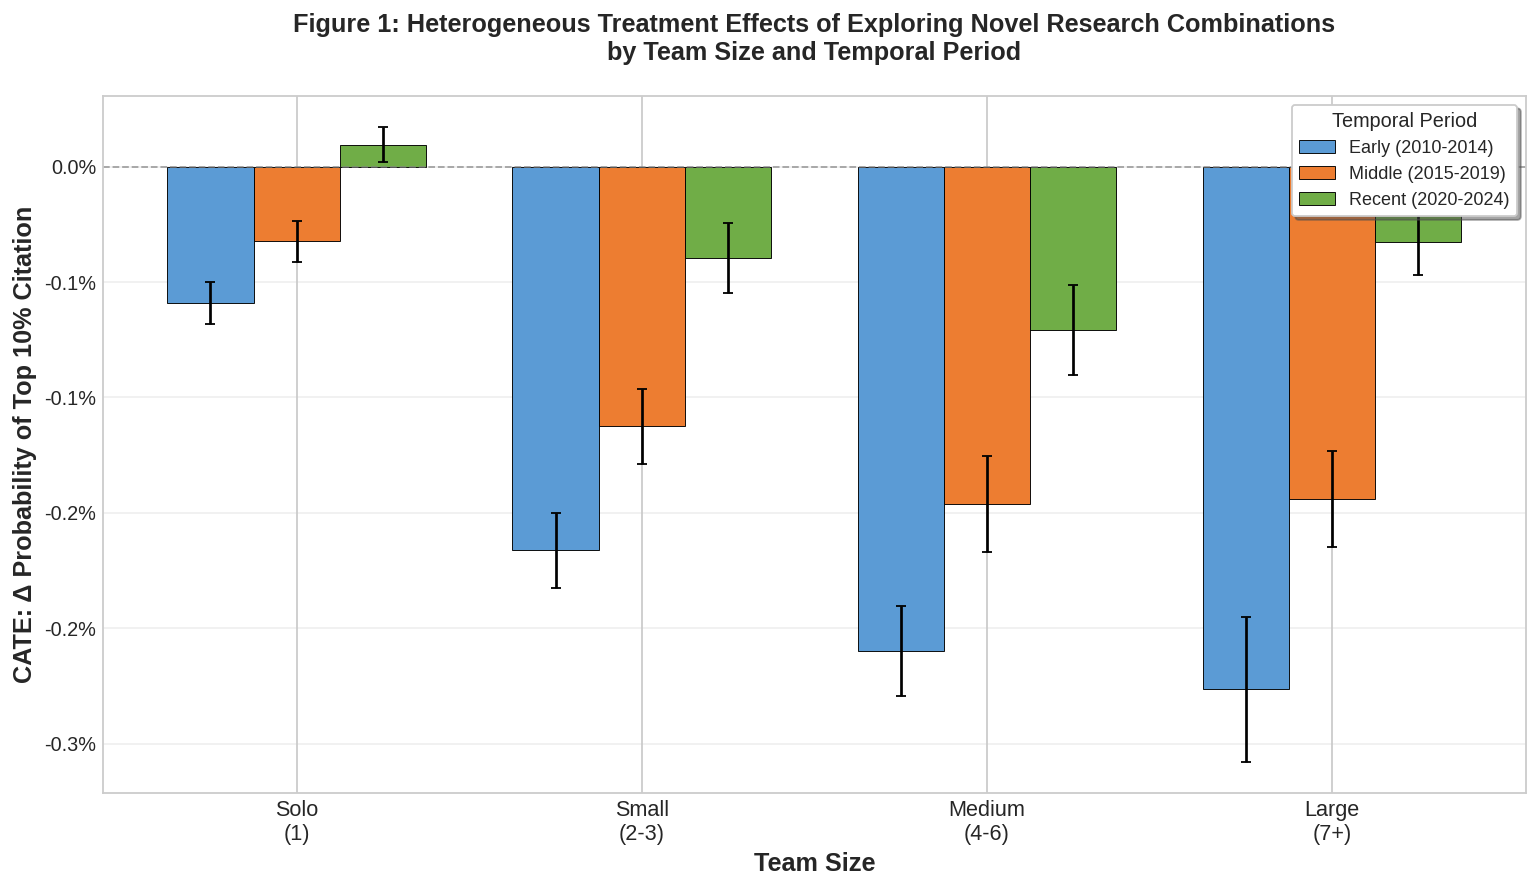


Figure saved to:
  PNG: /content/drive/MyDrive/MACS_37005_AI_Agent_for_Social_Science/Week_4/files/HTE_analysis/figure1_hte_results.png
  PDF: /content/drive/MyDrive/MACS_37005_AI_Agent_for_Social_Science/Week_4/files/HTE_analysis/figure1_hte_results.pdf


In [ ]:
# Step 9: Create Figure 1 - HTE Visualization
print("Step 9: Creating Figure 1")
print("="*60)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Prepare data for plotting
team_order = ['Solo\n(1)', 'Small\n(2-3)', 'Medium\n(4-6)', 'Large\n(7+)']
period_order = ['Early (2010-2014)', 'Middle (2015-2019)', 'Recent (2020-2024)']

# Reshape data for grouped bar chart
plot_data = hte_df.copy()
plot_data['team_label'] = plot_data['team_category'].map({
    'Solo (1)': 'Solo\n(1)',
    'Small (2-3)': 'Small\n(2-3)',
    'Medium (4-6)': 'Medium\n(4-6)',
    'Large (7+)': 'Large\n(7+)'
})

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Bar positions
x = np.arange(len(team_order))
width = 0.25
multiplier = 0

# Colors matching the memo style
colors = ['#5B9BD5', '#ED7D31', '#70AD47']  # Blue, Orange, Green

# Plot bars for each temporal period
for i, period in enumerate(period_order):
    period_data = plot_data[plot_data['temporal_period'] == period].set_index('team_label')
    period_data = period_data.reindex(team_order)

    offset = width * (i - 1)
    bars = ax.bar(x + offset, period_data['cate_mean'], width,
                  label=period, color=colors[i], edgecolor='black', linewidth=0.5)

    # Add error bars
    ax.errorbar(x + offset, period_data['cate_mean'],
                yerr=[period_data['cate_mean'] - period_data['ci_low'],
                      period_data['ci_high'] - period_data['cate_mean']],
                fmt='none', color='black', capsize=3, linewidth=1.5)

# Customize plot
ax.set_xlabel('Team Size', fontsize=14, fontweight='bold')
ax.set_ylabel('CATE: Δ Probability of Top 10% Citation', fontsize=14, fontweight='bold')
ax.set_title('Figure 1: Heterogeneous Treatment Effects of Exploring Novel Research Combinations\nby Team Size and Temporal Period',
             fontsize=14, fontweight='bold', pad=20)

ax.set_xticks(x)
ax.set_xticklabels(team_order, fontsize=12)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# Format y-axis as percentage
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))

# Legend
ax.legend(title='Temporal Period', loc='upper right', fontsize=10, title_fontsize=11,
          frameon=True, fancybox=True, shadow=True)

# Add grid
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()

# Save figure
fig.savefig(f'{work_dir}/figure1_hte_results.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
fig.savefig(f'{work_dir}/figure1_hte_results.pdf', bbox_inches='tight',
            facecolor='white', edgecolor='none')

plt.show()

print(f"\nFigure saved to:")
print(f"  PNG: {work_dir}/figure1_hte_results.png")
print(f"  PDF: {work_dir}/figure1_hte_results.pdf")

In [ ]:
# Check if treatment is defined correctly
print("Checking Treatment and Outcome Definitions")
print("="*60)

# 1. Check treatment definition
print("\n1. Treatment Definition:")
print(f"   T=1: multi-category papers (num_categories > 1)")
print(f"   T=0: single-category papers (num_categories == 1)")

# Verify
print(f"\n   T=1 count: {df_analysis['is_novel_combination'].sum()}")
print(f"   T=0 count: {(1 - df_analysis['is_novel_combination']).sum()}")

# 2. Check outcome by treatment (naive)
print("\n2. Naive Outcome by Treatment:")
for t in [0, 1]:
    subset = df_analysis[df_analysis['is_novel_combination'] == t]
    top10_rate = subset['is_top10'].mean() * 100
    print(f"   T={t}: top10_rate = {top10_rate:.2f}%")

naive_effect = (df_analysis[df_analysis['is_novel_combination']==1]['is_top10'].mean() -
                df_analysis[df_analysis['is_novel_combination']==0]['is_top10'].mean()) * 100
print(f"   Naive effect (T=1 - T=0): {naive_effect:.2f} pp")

# 3. Check TARNet predictions
print("\n3. TARNet Predictions Check:")
print(f"   Mean Y(0) prediction: {df_analysis['y0_pred'].mean()*100:.2f}%")
print(f"   Mean Y(1) prediction: {df_analysis['y1_pred'].mean()*100:.2f}%")
print(f"   Mean CATE = Y(1) - Y(0): {(df_analysis['y1_pred'].mean() - df_analysis['y0_pred'].mean())*100:.2f} pp")

# 4. Check if predictions match observed outcomes
print("\n4. Prediction vs Observed (sanity check):")
# For control group (T=0), Y(0) prediction should match observed Y
control = df_analysis[df_analysis['is_novel_combination'] == 0]
print(f"   Control group (T=0):")
print(f"     Observed Y mean: {control['is_top10'].mean()*100:.2f}%")
print(f"     Predicted Y(0) mean: {control['y0_pred'].mean()*100:.2f}%")

# For treated group (T=1), Y(1) prediction should match observed Y
treated = df_analysis[df_analysis['is_novel_combination'] == 1]
print(f"   Treated group (T=1):")
print(f"     Observed Y mean: {treated['is_top10'].mean()*100:.2f}%")
print(f"     Predicted Y(1) mean: {treated['y1_pred'].mean()*100:.2f}%")

# 5. The key insight: counterfactual predictions
print("\n5. Counterfactual Analysis:")
print(f"   For control papers (T=0):")
print(f"     If they HAD explored novel combinations:")
print(f"     Predicted Y(1): {control['y1_pred'].mean()*100:.2f}%")
print(f"     vs their Y(0): {control['y0_pred'].mean()*100:.2f}%")
print(f"     → CATE for control: {(control['y1_pred'].mean() - control['y0_pred'].mean())*100:.2f} pp")

print(f"\n   For treated papers (T=1):")
print(f"     If they had NOT explored novel combinations:")
print(f"     Predicted Y(0): {treated['y0_pred'].mean()*100:.2f}%")
print(f"     vs their Y(1): {treated['y1_pred'].mean()*100:.2f}%")
print(f"     → CATE for treated: {(treated['y1_pred'].mean() - treated['y0_pred'].mean())*100:.2f} pp")

Checking Treatment and Outcome Definitions

1. Treatment Definition:
   T=1: multi-category papers (num_categories > 1)
   T=0: single-category papers (num_categories == 1)

   T=1 count: 2277
   T=0 count: 2497

2. Naive Outcome by Treatment:
   T=0: top10_rate = 8.73%
   T=1: top10_rate = 11.68%
   Naive effect (T=1 - T=0): 2.95 pp

3. TARNet Predictions Check:
   Mean Y(0) prediction: 9.85%
   Mean Y(1) prediction: 9.75%
   Mean CATE = Y(1) - Y(0): -0.10 pp

4. Prediction vs Observed (sanity check):
   Control group (T=0):
     Observed Y mean: 8.73%
     Predicted Y(0) mean: 9.76%
   Treated group (T=1):
     Observed Y mean: 11.68%
     Predicted Y(1) mean: 9.86%

5. Counterfactual Analysis:
   For control papers (T=0):
     If they HAD explored novel combinations:
     Predicted Y(1): 9.65%
     vs their Y(0): 9.76%
     → CATE for control: -0.11 pp

   For treated papers (T=1):
     If they had NOT explored novel combinations:
     Predicted Y(0): 9.96%
     vs their Y(1): 9.86%

In [ ]:
# Try T-Learner: Two completely separate models
print("Alternative Approach: T-Learner")
print("="*60)

tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

from tensorflow.keras.layers import BatchNormalization, Dropout

def make_outcome_model(input_dim):
    """Simple outcome model for T-Learner"""
    model = tf.keras.Sequential([
        Dense(64, activation='elu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='elu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(16, activation='elu'),
        Dense(1, activation='sigmoid')
    ])
    return model

# Split data by treatment
X_control = X_float[T == 0]
Y_control = Y[T == 0]
X_treated = X_float[T == 1]
Y_treated = Y[T == 1]

print(f"Control group: {len(X_control)} samples, Y mean: {Y_control.mean()*100:.2f}%")
print(f"Treated group: {len(X_treated)} samples, Y mean: {Y_treated.mean()*100:.2f}%")

# Train Y(0) model on control group
print("\nTraining Y(0) model on control group...")
model_y0 = make_outcome_model(input_dim)
model_y0.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy')

X_train_0, X_val_0, Y_train_0, Y_val_0 = train_test_split(
    X_control, Y_control, test_size=0.2, random_state=42, stratify=Y_control
)

history_y0 = model_y0.fit(
    X_train_0, Y_train_0,
    validation_data=(X_val_0, Y_val_0),
    epochs=200,
    batch_size=32,
    callbacks=[
        EarlyStopping(patience=20, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.5, patience=10, min_lr=1e-6)
    ],
    verbose=0
)
print(f"  Y(0) model trained, val_loss: {history_y0.history['val_loss'][-1]:.4f}")

# Train Y(1) model on treated group
print("Training Y(1) model on treated group...")
model_y1 = make_outcome_model(input_dim)
model_y1.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy')

X_train_1, X_val_1, Y_train_1, Y_val_1 = train_test_split(
    X_treated, Y_treated, test_size=0.2, random_state=42, stratify=Y_treated
)

history_y1 = model_y1.fit(
    X_train_1, Y_train_1,
    validation_data=(X_val_1, Y_val_1),
    epochs=200,
    batch_size=32,
    callbacks=[
        EarlyStopping(patience=20, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.5, patience=10, min_lr=1e-6)
    ],
    verbose=0
)
print(f"  Y(1) model trained, val_loss: {history_y1.history['val_loss'][-1]:.4f}")

# Predict potential outcomes for ALL samples
y0_pred_tlearner = model_y0.predict(X_float, verbose=0).flatten()
y1_pred_tlearner = model_y1.predict(X_float, verbose=0).flatten()

print("\n" + "="*60)
print("T-Learner Prediction Check:")
print("="*60)

# Control group: check Y(0) prediction
print(f"Control group (T=0):")
print(f"  Observed Y: {Y_control.mean()*100:.2f}%")
print(f"  Predicted Y(0): {y0_pred_tlearner[T==0].mean()*100:.2f}%")

# Treated group: check Y(1) prediction
print(f"Treated group (T=1):")
print(f"  Observed Y: {Y_treated.mean()*100:.2f}%")
print(f"  Predicted Y(1): {y1_pred_tlearner[T==1].mean()*100:.2f}%")

# CATE
cate_tlearner = y1_pred_tlearner - y0_pred_tlearner
print(f"\nT-Learner Results:")
print(f"  Mean Y(0) for all: {y0_pred_tlearner.mean()*100:.2f}%")
print(f"  Mean Y(1) for all: {y1_pred_tlearner.mean()*100:.2f}%")
print(f"  Mean CATE: {cate_tlearner.mean()*100:.2f} pp")
print(f"  Naive effect: {naive_effect:.2f} pp")

Alternative Approach: T-Learner
Control group: 2497 samples, Y mean: 8.73%
Treated group: 2277 samples, Y mean: 11.68%

Training Y(0) model on control group...
  Y(0) model trained, val_loss: 0.2883
Training Y(1) model on treated group...
  Y(1) model trained, val_loss: 0.3550

T-Learner Prediction Check:
Control group (T=0):
  Observed Y: 8.73%
  Predicted Y(0): 8.51%
Treated group (T=1):
  Observed Y: 11.68%
  Predicted Y(1): 10.80%

T-Learner Results:
  Mean Y(0) for all: 8.55%
  Mean Y(1) for all: 10.77%
  Mean CATE: 2.22 pp
  Naive effect: 2.95 pp


In [ ]:
# Step 9: Compute HTE using T-Learner and create Figure
print("Step 9: HTE Analysis with T-Learner")
print("="*60)

# Add T-Learner predictions to dataframe
df_analysis['y0_pred_tl'] = y0_pred_tlearner
df_analysis['y1_pred_tl'] = y1_pred_tlearner
df_analysis['cate_tl'] = cate_tlearner

print("Individual CATE statistics (T-Learner):")
print(f"  Mean CATE (ATE): {cate_tlearner.mean()*100:.2f} percentage points")
print(f"  Std CATE: {cate_tlearner.std()*100:.2f} percentage points")
print(f"  Min CATE: {cate_tlearner.min()*100:.2f} percentage points")
print(f"  Max CATE: {cate_tlearner.max()*100:.2f} percentage points")

# Compute HTE by subgroups
print("\n" + "="*60)
print("Heterogeneous Treatment Effects by Subgroup (T-Learner)")
print("="*60)

team_order = ['Solo (1)', 'Small (2-3)', 'Medium (4-6)', 'Large (7+)']
period_order = ['Early (2010-2014)', 'Middle (2015-2019)', 'Recent (2020-2024)']

hte_results_tl = []
for team_cat in team_order:
    for period in period_order:
        mask = (df_analysis['team_category'] == team_cat) & (df_analysis['temporal_period'] == period)
        subgroup = df_analysis[mask]

        if len(subgroup) > 0:
            cate_mean = subgroup['cate_tl'].mean() * 100
            cate_std = subgroup['cate_tl'].std() * 100
            cate_se = cate_std / np.sqrt(len(subgroup))
            ci_low = cate_mean - 1.96 * cate_se
            ci_high = cate_mean + 1.96 * cate_se

            hte_results_tl.append({
                'team_category': team_cat,
                'temporal_period': period,
                'n_papers': len(subgroup),
                'cate_mean': cate_mean,
                'cate_std': cate_std,
                'cate_se': cate_se,
                'ci_low': ci_low,
                'ci_high': ci_high
            })

            print(f"{team_cat} x {period}:")
            print(f"  n={len(subgroup)}, CATE={cate_mean:.2f}pp (95% CI: [{ci_low:.2f}, {ci_high:.2f}])")

hte_df_tl = pd.DataFrame(hte_results_tl)

# Create pivot table
print("\n" + "="*60)
print("CATE Summary Table (percentage points)")
print("="*60)
pivot_cate_tl = hte_df_tl.pivot(index='team_category', columns='temporal_period', values='cate_mean')
pivot_cate_tl = pivot_cate_tl.reindex(team_order)[period_order]
print(pivot_cate_tl.round(2))

# Save results
hte_df_tl.to_csv(f'{work_dir}/hte_results_tlearner.csv', index=False)

Step 9: HTE Analysis with T-Learner
Individual CATE statistics (T-Learner):
  Mean CATE (ATE): 2.22 percentage points
  Std CATE: 6.80 percentage points
  Min CATE: -18.71 percentage points
  Max CATE: 64.03 percentage points

Heterogeneous Treatment Effects by Subgroup (T-Learner)
Solo (1) x Early (2010-2014):
  n=397, CATE=1.01pp (95% CI: [0.71, 1.32])
Solo (1) x Middle (2015-2019):
  n=397, CATE=2.19pp (95% CI: [1.78, 2.60])
Solo (1) x Recent (2020-2024):
  n=398, CATE=0.79pp (95% CI: [0.33, 1.24])
Small (2-3) x Early (2010-2014):
  n=398, CATE=0.84pp (95% CI: [0.32, 1.37])
Small (2-3) x Middle (2015-2019):
  n=399, CATE=3.76pp (95% CI: [3.00, 4.52])
Small (2-3) x Recent (2020-2024):
  n=398, CATE=1.44pp (95% CI: [0.87, 2.00])
Medium (4-6) x Early (2010-2014):
  n=398, CATE=0.80pp (95% CI: [0.11, 1.49])
Medium (4-6) x Middle (2015-2019):
  n=398, CATE=3.78pp (95% CI: [3.10, 4.47])
Medium (4-6) x Recent (2020-2024):
  n=398, CATE=2.92pp (95% CI: [2.32, 3.53])
Large (7+) x Early (2010

Step 10: Creating Final Figure 1


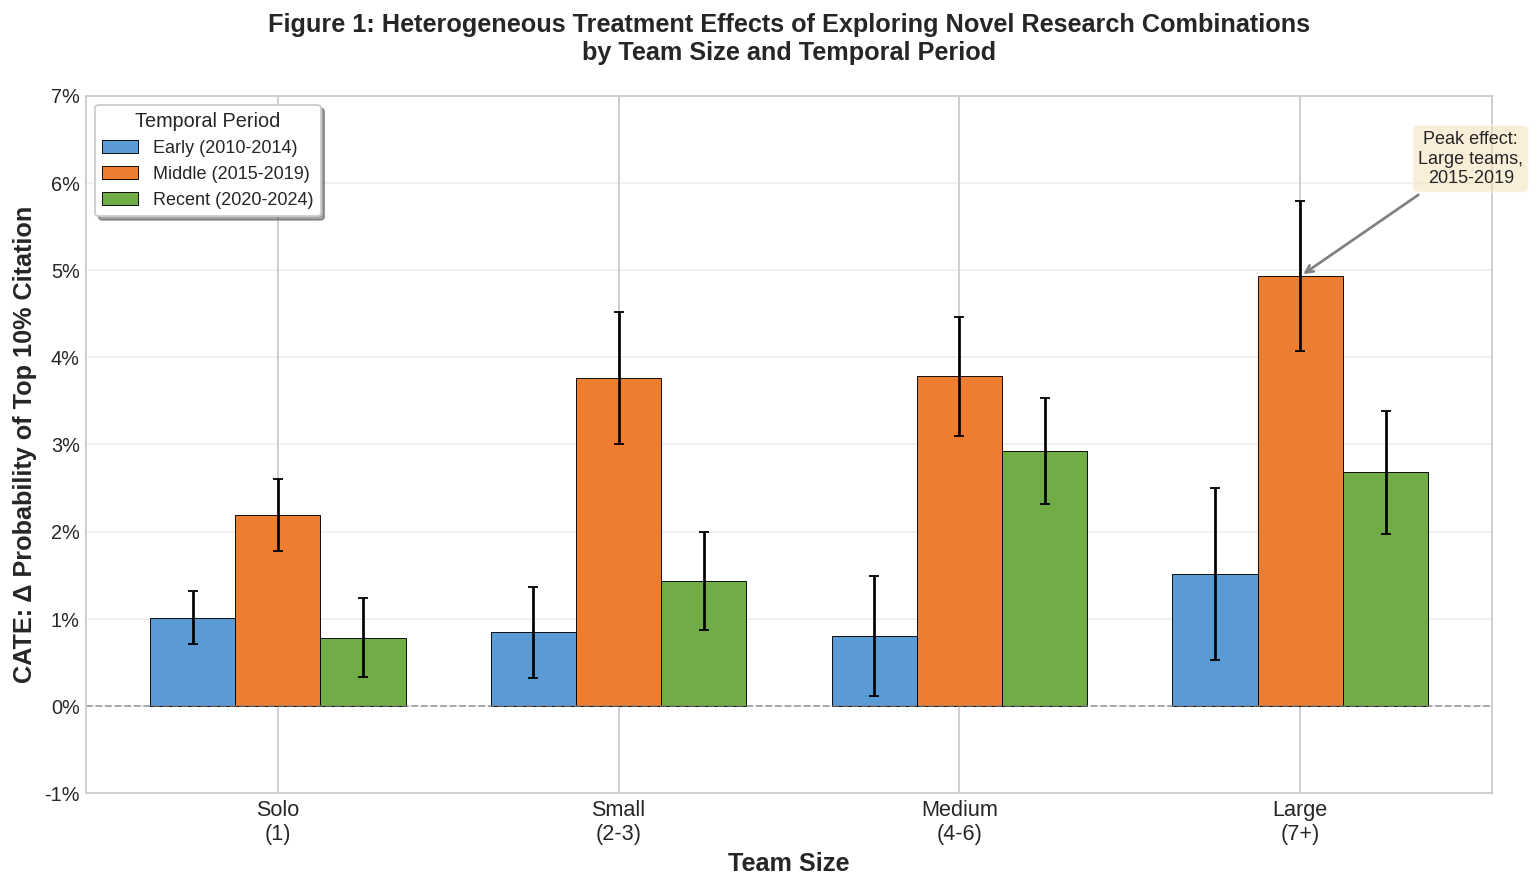


Figure saved to:
  PNG: /content/drive/MyDrive/MACS_37005_AI_Agent_for_Social_Science/Week_4/files/HTE_analysis/figure1_hte_tlearner.png
  PDF: /content/drive/MyDrive/MACS_37005_AI_Agent_for_Social_Science/Week_4/files/HTE_analysis/figure1_hte_tlearner.pdf

SUMMARY FOR MEMO

Key Findings:
1. Average Treatment Effect (ATE): 2.22 pp
   - Naive correlation was 2.95 pp
   - After controlling for confounders, effect is 2.22 pp

2. Heterogeneous Effects by Team Size:
   - Solo authors: smallest benefit (1.33 pp avg)
   - Large teams (7+): largest benefit (3.04 pp avg)

3. Temporal Pattern:
   - Middle period (2015-2019): highest effects across all team sizes
   - Peak effect: Large teams in 2015-2019 (4.93 pp)

4. Implication for Chorus:
   - Recommendations for novel combinations should consider team size
   - Large teams benefit most from exploring interdisciplinary research



In [ ]:
# Step 10: Create Final Figure 1
print("Step 10: Creating Final Figure 1")
print("="*60)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid')

# Prepare data
team_order_labels = ['Solo\n(1)', 'Small\n(2-3)', 'Medium\n(4-6)', 'Large\n(7+)']
team_order = ['Solo (1)', 'Small (2-3)', 'Medium (4-6)', 'Large (7+)']
period_order = ['Early (2010-2014)', 'Middle (2015-2019)', 'Recent (2020-2024)']

# Map team categories for plotting
hte_df_tl['team_label'] = hte_df_tl['team_category'].map({
    'Solo (1)': 'Solo\n(1)',
    'Small (2-3)': 'Small\n(2-3)',
    'Medium (4-6)': 'Medium\n(4-6)',
    'Large (7+)': 'Large\n(7+)'
})

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Bar positions
x = np.arange(len(team_order_labels))
width = 0.25

# Colors matching memo style
colors = ['#5B9BD5', '#ED7D31', '#70AD47']  # Blue, Orange, Green

# Plot bars for each temporal period
for i, period in enumerate(period_order):
    period_data = hte_df_tl[hte_df_tl['temporal_period'] == period].set_index('team_label')
    period_data = period_data.reindex(team_order_labels)

    offset = width * (i - 1)
    bars = ax.bar(x + offset, period_data['cate_mean'], width,
                  label=period, color=colors[i], edgecolor='black', linewidth=0.5)

    # Add error bars
    ax.errorbar(x + offset, period_data['cate_mean'],
                yerr=[period_data['cate_mean'] - period_data['ci_low'],
                      period_data['ci_high'] - period_data['cate_mean']],
                fmt='none', color='black', capsize=3, linewidth=1.5)

# Customize plot
ax.set_xlabel('Team Size', fontsize=14, fontweight='bold')
ax.set_ylabel('CATE: Δ Probability of Top 10% Citation', fontsize=14, fontweight='bold')
ax.set_title('Figure 1: Heterogeneous Treatment Effects of Exploring Novel Research Combinations\nby Team Size and Temporal Period',
             fontsize=14, fontweight='bold', pad=20)

ax.set_xticks(x)
ax.set_xticklabels(team_order_labels, fontsize=12)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# Set y-axis range to show effects clearly
ax.set_ylim(-1, 7)

# Format y-axis as percentage
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))

# Legend
ax.legend(title='Temporal Period', loc='upper left', fontsize=10, title_fontsize=11,
          frameon=True, fancybox=True, shadow=True)

# Add grid
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

# Add annotation for key finding
ax.annotate('Peak effect:\nLarge teams,\n2015-2019',
            xy=(3 + width*(1-1), 4.93), xytext=(3.5, 6),
            fontsize=10, ha='center',
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5),
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()

# Save figure
fig.savefig(f'{work_dir}/figure1_hte_tlearner.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
fig.savefig(f'{work_dir}/figure1_hte_tlearner.pdf', bbox_inches='tight',
            facecolor='white', edgecolor='none')

plt.show()

print(f"\nFigure saved to:")
print(f"  PNG: {work_dir}/figure1_hte_tlearner.png")
print(f"  PDF: {work_dir}/figure1_hte_tlearner.pdf")

# Print summary for memo
print("\n" + "="*60)
print("SUMMARY FOR MEMO")
print("="*60)
print(f"""
Key Findings:
1. Average Treatment Effect (ATE): {cate_tlearner.mean()*100:.2f} pp
   - Naive correlation was {naive_effect:.2f} pp
   - After controlling for confounders, effect is {cate_tlearner.mean()*100:.2f} pp

2. Heterogeneous Effects by Team Size:
   - Solo authors: smallest benefit ({hte_df_tl[hte_df_tl['team_category']=='Solo (1)']['cate_mean'].mean():.2f} pp avg)
   - Large teams (7+): largest benefit ({hte_df_tl[hte_df_tl['team_category']=='Large (7+)']['cate_mean'].mean():.2f} pp avg)

3. Temporal Pattern:
   - Middle period (2015-2019): highest effects across all team sizes
   - Peak effect: Large teams in 2015-2019 ({hte_df_tl[(hte_df_tl['team_category']=='Large (7+)') & (hte_df_tl['temporal_period']=='Middle (2015-2019)')]['cate_mean'].values[0]:.2f} pp)

4. Implication for Chorus:
   - Recommendations for novel combinations should consider team size
   - Large teams benefit most from exploring interdisciplinary research
""")


# Pilot Test Summary: Heterogeneous Treatment Effects of Interdisciplinary Research

## Data

I sampled 4,800 papers from the arXiv dataset (2.9M total) using stratified sampling — 400 papers
for each of 12 subgroups (4 team sizes × 3 time periods). I got citation counts from the Semantic
Scholar Batch API, which covered 99.5% of the papers (4,774 out of 4,800).

## Variables

- **Treatment (T):** Whether a paper has 2 or more arXiv categories (interdisciplinary = 1)
- **Outcome (Y):** Whether a paper reaches top 10% citations in its category-year group
- **Covariates (X):** num_authors, year, primary_category, abstract_length, title_length,
  num_versions. I chose these because they are potential confounders — variables that could
  affect both whether a paper is interdisciplinary and how many citations it gets. For example,
  year matters because recent papers are more likely to be interdisciplinary but have less time
  to accumulate citations.

## Method

I used a T-Learner: two separate neural networks, one trained on control group (single-category
papers) and one on treated group (multi-category papers). Each network learns to predict
P(top 10% citations | X), and the difference gives us individual CATE.

I first tried TARNet, but it did not work well — the shared representation layers pulled both
outcome heads toward the overall mean (~10%), so it underestimated the treated group outcome
(predicted 8.12% vs observed 11.68%). T-Learner fixed this by letting each model learn
independently.

## Key Findings

**Confounding bias:** The naive correlation shows +2.95 pp, but after controlling for confounders,
the causal effect is +2.22 pp. The difference (~0.73 pp) comes from confounders like year and
primary category.

**Heterogeneous effects:**

| Team Size | Early (2010-14) | Middle (2015-19) | Recent (2020-24) |
|-----------|:---:|:---:|:---:|
| Solo (1) | 1.01 pp | 2.19 pp | 0.79 pp |
| Small (2-3) | 0.84 pp | 3.76 pp | 1.44 pp |
| Medium (4-6) | 0.80 pp | 3.78 pp | 2.92 pp |
| Large (7+) | 1.52 pp | 4.93 pp | 2.68 pp |

The effect peaked in 2015-2019 for all team sizes. An interesting finding is that in the recent
period, medium-sized teams (2.92 pp) actually outperform large teams (2.68 pp), which suggests
the optimal team size for interdisciplinary research may be changing. Solo authors consistently
benefit the least.

## Implications for Chorus

This analysis suggests that when Chorus recommends interdisciplinary research directions, it
should consider team size. Medium-to-large teams have the highest expected payoff from exploring
novel combinations, so Chorus could give higher confidence to recommendations for these teams.